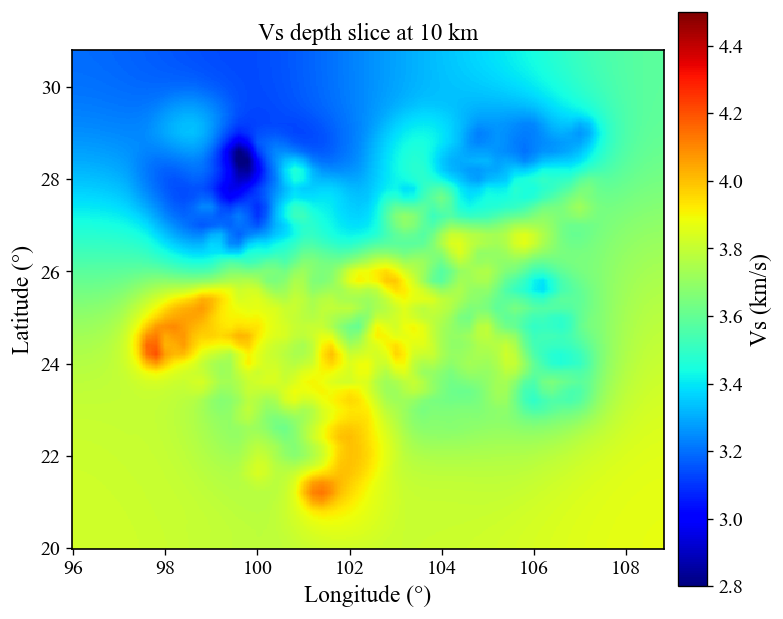

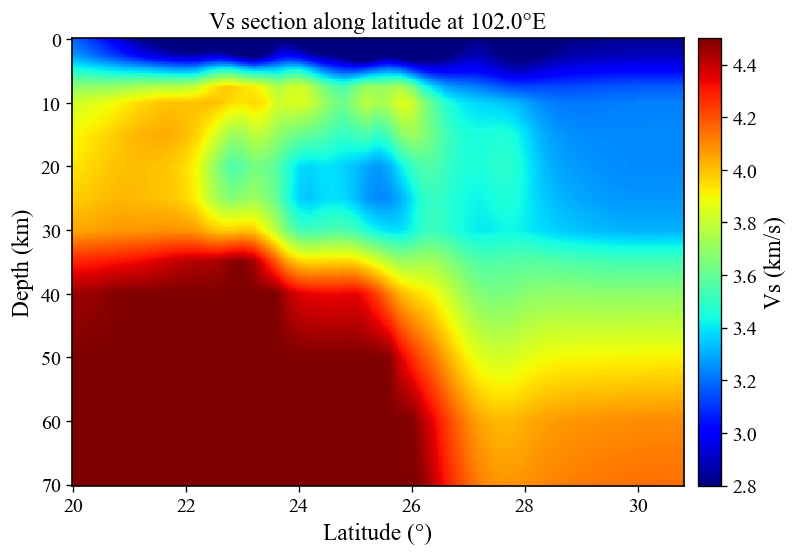

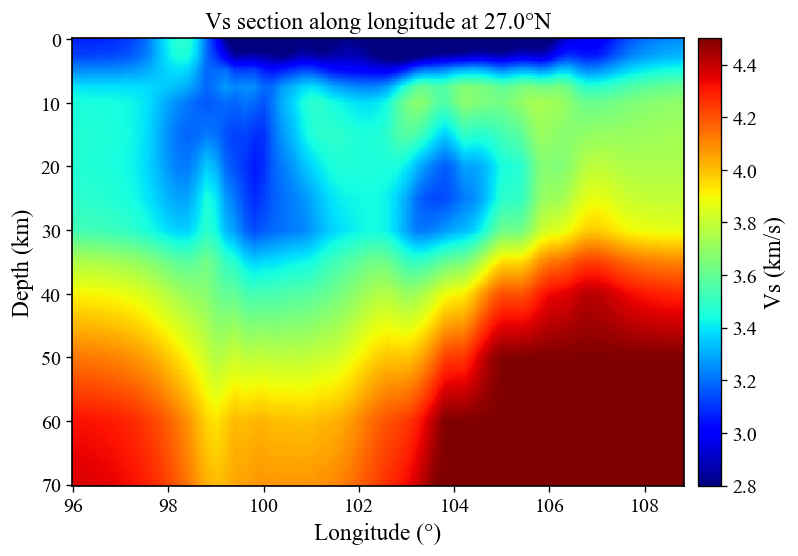

In [ ]:
from tarfile import data_filter

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.interpolate import RegularGridInterpolator


# =========================================================
# 1. 读取四列速度模型
# =========================================================
def read_vs_dat(dat_file):
    """
    读取四列格式:
    lon lat dep vs
    """
    data = np.loadtxt(dat_file)
    lon = data[:, 0]
    lat = data[:, 1]
    dep = data[:, 2]
    vs = data[:, 3]
    return lon, lat, dep, vs


def build_3d_model(lon, lat, dep, vs):
    """
    构造成规则 3D 网格:
    vs_3d[idep, ilon, ilat]

    约定:
      lon 升序
      lat 降序（北->南）
      dep 升序（浅->深）
    """
    lons = np.sort(np.unique(np.round(lon, 6)))
    lats = np.sort(np.unique(np.round(lat, 6)))[::-1]
    deps = np.sort(np.unique(np.round(dep, 6)))

    lon_to_i = {v: i for i, v in enumerate(lons)}
    lat_to_i = {v: i for i, v in enumerate(lats)}
    dep_to_i = {v: i for i, v in enumerate(deps)}

    vs_3d = np.full((len(deps), len(lons), len(lats)), np.nan)

    for lo, la, de, vv in zip(lon, lat, dep, vs):
        i_lon = lon_to_i[round(lo, 6)]
        i_lat = lat_to_i[round(la, 6)]
        i_dep = dep_to_i[round(de, 6)]
        vs_3d[i_dep, i_lon, i_lat] = vv

    return lons, lats, deps, vs_3d


# =========================================================
# 2. 插值函数
# =========================================================
def interpolate_2d(x, y, z, nx_new=300, ny_new=300):
    """
    对规则网格二维数据做插值
    输入:
        x: 1D, 长度 nx
        y: 1D, 长度 ny
        z: shape = (ny, nx)
    返回:
        Xnew, Ynew, Znew
    """
    # RegularGridInterpolator 要求坐标升序
    x_in = np.array(x)
    y_in = np.array(y)
    z_in = np.array(z)

    if np.any(np.diff(x_in) < 0):
        ix = np.argsort(x_in)
        x_in = x_in[ix]
        z_in = z_in[:, ix]

    if np.any(np.diff(y_in) < 0):
        iy = np.argsort(y_in)
        y_in = y_in[iy]
        z_in = z_in[iy, :]

    f = RegularGridInterpolator(
        (y_in, x_in), z_in,
        method="linear",
        bounds_error=False,
        fill_value=np.nan
    )

    x_new = np.linspace(x_in.min(), x_in.max(), nx_new)
    y_new = np.linspace(y_in.min(), y_in.max(), ny_new)
    Xnew, Ynew = np.meshgrid(x_new, y_new)

    pts = np.column_stack([Ynew.ravel(), Xnew.ravel()])
    Znew = f(pts).reshape(Ynew.shape)

    return Xnew, Ynew, Znew


# =========================================================
# 3. 统一绘图风格
# =========================================================
def set_plot_style():
    rcParams["font.family"] = "Times New Roman"
    rcParams["font.size"] = 12
    rcParams["axes.labelsize"] = 14
    rcParams["axes.titlesize"] = 14
    rcParams["xtick.labelsize"] = 12
    rcParams["ytick.labelsize"] = 12
    rcParams["figure.dpi"] = 120


# =========================================================
# 4. 横切面：固定深度
# =========================================================
def plot_depth_slice(dat_file, target_depth,
                     out_png=None, out_pdf=None,
                     vmin=None, vmax=None,
                     interp_nx=350, interp_ny=350,
                     cmap="jet", title=None):
    """
    固定深度画横切面 lon-lat
    """
    set_plot_style()

    lon, lat, dep, vs = read_vs_dat(dat_file)
    lons, lats, deps, vs_3d = build_3d_model(lon, lat, dep, vs)

    idep = np.argmin(np.abs(deps - target_depth))
    dep_sel = deps[idep]

    # 原始切片 shape = (nlon, nlat)
    slice_raw = vs_3d[idep, :, :]

    # 转成 z(lat, lon)
    Z = slice_raw.T

    Xnew, Ynew, Znew = interpolate_2d(
        lons, lats, Z,
        nx_new=interp_nx,
        ny_new=interp_ny
    )

    fig, ax = plt.subplots(figsize=(6.8, 5.4))

    pcm = ax.pcolormesh(Xnew, Ynew, Znew, shading="auto",
                        cmap=cmap, vmin=vmin, vmax=vmax)

    cbar = plt.colorbar(pcm, ax=ax, pad=0.02)
    cbar.set_label("Vs (km/s)")

    ax.set_xlabel("Longitude (°)")
    ax.set_ylabel("Latitude (°)")
    ax.set_title(title if title else f"Depth slice at {dep_sel:.1f} km")
    ax.set_aspect("equal")

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

    plt.tight_layout()

    if out_png:
        plt.savefig(out_png, dpi=300, bbox_inches="tight")
        print(f"已保存: {out_png}")
    if out_pdf:
        plt.savefig(out_pdf, bbox_inches="tight")
        print(f"已保存: {out_pdf}")

    plt.show()


# =========================================================
# 5. 纵剖面：固定经度，画 lat-depth
# =========================================================
def plot_lat_depth_section(dat_file, fixed_lon,
                           out_png=None, out_pdf=None,
                           vmin=None, vmax=None,
                           interp_nx=350, interp_ny=250,
                           cmap="jet", title=None):
    """
    固定经度，画 latitude-depth 剖面
    """
    set_plot_style()

    lon, lat, dep, vs = read_vs_dat(dat_file)
    lons, lats, deps, vs_3d = build_3d_model(lon, lat, dep, vs)

    ilon = np.argmin(np.abs(lons - fixed_lon))
    lon_sel = lons[ilon]

    # [dep, lat]
    section = vs_3d[:, ilon, :]
    # 转成 z(depth, lat) -> 这里 x=lat, y=depth
    Z = section

    Xnew, Ynew, Znew = interpolate_2d(
        lats, deps, Z,
        nx_new=interp_nx,
        ny_new=interp_ny
    )

    fig, ax = plt.subplots(figsize=(7.0, 4.8))

    pcm = ax.pcolormesh(Xnew, Ynew, Znew, shading="auto",
                        cmap=cmap, vmin=vmin, vmax=vmax)

    cbar = plt.colorbar(pcm, ax=ax, pad=0.02)
    cbar.set_label("Vs (km/s)")

    ax.invert_yaxis()
    ax.set_xlabel("Latitude (°)")
    ax.set_ylabel("Depth (km)")
    ax.set_title(title if title else f"Lat-depth section at lon = {lon_sel:.2f}°")

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

    plt.tight_layout()

    if out_png:
        plt.savefig(out_png, dpi=300, bbox_inches="tight")
        print(f"已保存: {out_png}")
    if out_pdf:
        plt.savefig(out_pdf, bbox_inches="tight")
        print(f"已保存: {out_pdf}")

    plt.show()


# =========================================================
# 6. 纵剖面：固定纬度，画 lon-depth
# =========================================================
def plot_lon_depth_section(dat_file, fixed_lat,
                           out_png=None, out_pdf=None,
                           vmin=None, vmax=None,
                           interp_nx=350, interp_ny=250,
                           cmap="jet", title=None):
    """
    固定纬度，画 longitude-depth 剖面
    """
    set_plot_style()

    lon, lat, dep, vs = read_vs_dat(dat_file)
    lons, lats, deps, vs_3d = build_3d_model(lon, lat, dep, vs)

    ilat = np.argmin(np.abs(lats - fixed_lat))
    lat_sel = lats[ilat]

    # [dep, lon]
    section = vs_3d[:, :, ilat]
    # x=lon, y=depth
    Z = section

    Xnew, Ynew, Znew = interpolate_2d(
        lons, deps, Z,
        nx_new=interp_nx,
        ny_new=interp_ny
    )

    fig, ax = plt.subplots(figsize=(7.0, 4.8))

    pcm = ax.pcolormesh(Xnew, Ynew, Znew, shading="auto",
                        cmap=cmap, vmin=vmin, vmax=vmax)

    cbar = plt.colorbar(pcm, ax=ax, pad=0.02)
    cbar.set_label("Vs (km/s)")

    ax.invert_yaxis()
    ax.set_xlabel("Longitude (°)")
    ax.set_ylabel("Depth (km)")
    ax.set_title(title if title else f"Lon-depth section at lat = {lat_sel:.2f}°")

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

    plt.tight_layout()

    if out_png:
        plt.savefig(out_png, dpi=300, bbox_inches="tight")
        print(f"已保存: {out_png}")
    if out_pdf:
        plt.savefig(out_pdf, bbox_inches="tight")
        print(f"已保存: {out_pdf}")

    plt.show()



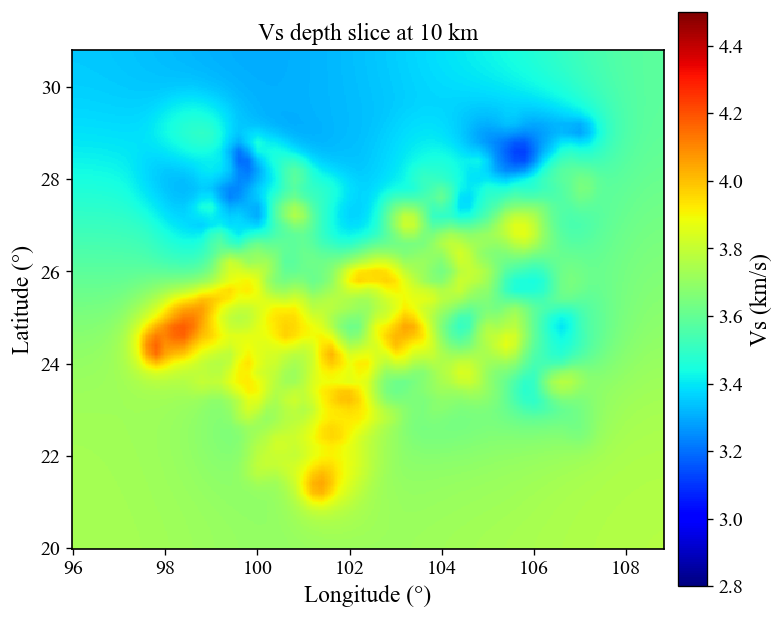

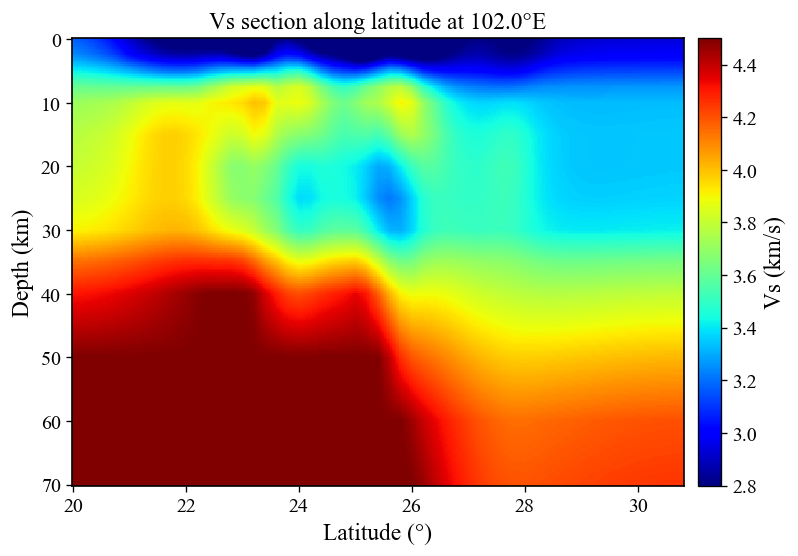

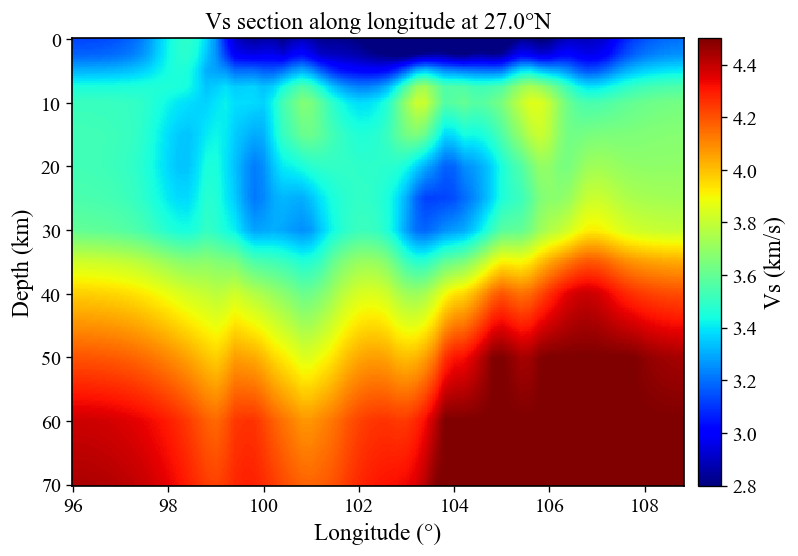

In [4]:

# =========================================================
# 7. 主程序示例
# =========================================================
if __name__ == "__main__":
    #dat_file = "/public/home/xiangyy/Project_ZHv2.0/tools/model_iter10.dat"
    dat_file = '/public/home/xiangyy/Project_ZHv2.0/datasets_Yunnan/model_iter10.dat'
    # 统一色标，便于不同图比较
    vmin = 2.8
    vmax = 4.5

    # ---------- 横切面 ----------
    plot_depth_slice(
        dat_file=dat_file,
        target_depth=10.0,
        vmin=vmin,
        vmax=vmax,
        interp_nx=400,
        interp_ny=400,
        title="Vs depth slice at 10 km"
    )

    # ---------- 固定经度的纵剖面 ----------
    plot_lat_depth_section(
        dat_file=dat_file,
        fixed_lon=102.0,
        vmin=vmin,
        vmax=vmax,
        interp_nx=400,
        interp_ny=260,
        title="Vs section along latitude at 102.0°E"
    )

    # ---------- 固定纬度的纵剖面 ----------
    plot_lon_depth_section(
        dat_file=dat_file,
        fixed_lat=27.0,
        vmin=vmin,
        vmax=vmax,
        interp_nx=400,
        interp_ny=260,
        title="Vs section along longitude at 27.0°N"
    )